# Diabetes Risk Prediction

## Objective
- Creating predictive models to pinpoint individuals at high risk for diabetes, facilitating early interventions and disease management.
- Determine the critical factors contributing to diabetes risk to guide effective prevention measures.

#### A. Data Preparation and Initial Analysis

##### A.1. Load the necessary Python libraries.

In [34]:
# Suppress specific warnings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Data manipulation
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix

# Machine learning: preprocessing and model selection
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV

# Machine learning: models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Machine learning: metrics
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score, 
    confusion_matrix, 
    classification_report, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score,
    mean_squared_error
)

# Machine learning: feature selection
from sklearn.feature_selection import SelectKBest, chi2, f_classif

# Statistical analysis
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2_contingency

# Advanced machine learning (gradient boosting)
import xgboost as xgb


##### A.2. Data Loading

In [4]:
# Load the dataset from a CSV file
data = pd.read_csv("diabetes_binary.csv")

##### A.3. Data Inspection

In [5]:
data.shape

(236378, 22)

In [6]:
data

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,0,1.0,1,15.0,1.0,0.0,0.0,0,1,...,1,0.0,5.0,10.0,20.0,0.0,0,11,4.0,5.0
1,1.0,1,0.0,1,28.0,0.0,0.0,1.0,0,1,...,1,0.0,2.0,0.0,0.0,0.0,0,11,4.0,3.0
2,1.0,1,1.0,1,33.0,0.0,0.0,0.0,1,1,...,1,0.0,2.0,10.0,0.0,0.0,0,9,4.0,7.0
3,1.0,0,1.0,1,29.0,0.0,1.0,1.0,1,1,...,1,0.0,5.0,0.0,30.0,1.0,1,12,3.0,4.0
4,0.0,0,0.0,1,24.0,1.0,0.0,0.0,0,0,...,1,0.0,3.0,0.0,0.0,1.0,1,13,5.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236373,1.0,1,1.0,1,21.0,0.0,0.0,0.0,1,1,...,1,0.0,4.0,0.0,0.0,0.0,1,10,2.0,3.0
236374,0.0,1,0.0,1,25.0,1.0,0.0,0.0,1,1,...,0,1.0,2.0,20.0,0.0,0.0,0,3,4.0,5.0
236375,0.0,0,1.0,1,31.0,0.0,0.0,0.0,1,1,...,1,0.0,2.0,0.0,0.0,0.0,1,7,6.0,10.0
236376,0.0,1,0.0,1,24.0,0.0,0.0,0.0,1,1,...,1,0.0,2.0,0.0,0.0,0.0,1,10,4.0,6.0


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236378 entries, 0 to 236377
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       236378 non-null  float64
 1   HighBP                236378 non-null  int64  
 2   HighChol              236378 non-null  float64
 3   CholCheck             236378 non-null  int64  
 4   BMI                   236378 non-null  float64
 5   Smoker                236378 non-null  float64
 6   Stroke                236378 non-null  float64
 7   HeartDiseaseorAttack  236378 non-null  float64
 8   PhysActivity          236378 non-null  int64  
 9   Fruits                236378 non-null  int64  
 10  Veggies               236378 non-null  int64  
 11  HvyAlcoholConsump     236378 non-null  int64  
 12  AnyHealthcare         236378 non-null  int64  
 13  NoDocbcCost           236378 non-null  float64
 14  GenHlth               236378 non-null  float64
 15  

In [8]:
data.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,236378.000000,236378.000000,236378.000000,236378.000000,236378.000000,236378.000000,236378.000000,236378.000000,236378.000000,236378.000000,...,236378.000000,236378.000000,236378.000000,236378.000000,236378.000000,236378.000000,236378.000000,236378.000000,236378.000000,236378.000000
mean,0.142010,0.418558,0.402059,0.963347,28.953579,0.411997,0.038900,0.086548,0.779231,0.621259,...,0.962573,0.063737,2.480717,3.937710,3.751297,0.153948,0.477824,7.863930,5.139099,6.927451
std,0.349061,0.493324,0.490315,0.187909,6.552055,0.492196,0.193356,0.281172,0.414766,0.485074,...,0.189807,0.244284,1.029134,7.886506,8.245907,0.360900,0.499509,3.236997,0.946185,2.375450
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,5.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,28.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,32.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,4.000000,2.000000,0.000000,1.000000,10.000000,6.000000,9.000000
max,1.000000,1.000000,1.000000,1.000000,99.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,11.000000


#### B. Data Cleaning

Prepare the data for modeling by handling missing values or null values, Handling duplicate values 

##### B.1. Duplicate Rows

In [9]:
# Check for duplicate records in the dataset. Remove any duplicates to ensure the data integrity.
duplicates = data[data.duplicated()]
print("Duplicate Rows : ",len(duplicates))

Duplicate Rows :  13135


In [10]:
# Remove all duplicate rows
data.drop_duplicates(inplace = True)

In [11]:
# Rechecking for duplicate rows
duplicates = data[data.duplicated()]
print("Duplicate Rows : ",len(duplicates))

Duplicate Rows :  0


##### B.2. Missing or Null Values

In [12]:
# Check each column for missing values to ensure the dataset is complete
missing_values = data.isnull().sum()
print(missing_values)

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


Dataset doesnot contain any missing or null values

In [13]:
# Inspecting Data Types and Structure
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 223243 entries, 0 to 236377
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       223243 non-null  float64
 1   HighBP                223243 non-null  int64  
 2   HighChol              223243 non-null  float64
 3   CholCheck             223243 non-null  int64  
 4   BMI                   223243 non-null  float64
 5   Smoker                223243 non-null  float64
 6   Stroke                223243 non-null  float64
 7   HeartDiseaseorAttack  223243 non-null  float64
 8   PhysActivity          223243 non-null  int64  
 9   Fruits                223243 non-null  int64  
 10  Veggies               223243 non-null  int64  
 11  HvyAlcoholConsump     223243 non-null  int64  
 12  AnyHealthcare         223243 non-null  int64  
 13  NoDocbcCost           223243 non-null  float64
 14  GenHlth               223243 non-null  float64
 15  MentH

##### B.3. Data Type Conversion for Efficiency
We enhance the dataset's memory efficiency by converting specified binary columns to boolean data types. We print the memory usage before and after the operation to demonstrate the effectiveness of this optimization in reducing the dataset's memory consumption.

In [14]:
# Convert data types of certain columns to reduce memory usage, optimizing computational efficiency.
data["BMI"] = data["BMI"].astype("float32")  # Convert BMI to float32 to reduce memory consumption
data["Age"] = data["Age"].astype("int8")     # Convert Age to int8 to save memory

#### C. Exploratory Data Analysis (EDA)

##### Summary Statistics

In [15]:
from tabulate import tabulate

# Assuming 'data' is your DataFrame
summary_stats = data.describe().T

# Resetting the index to add the index as a column, which can act as a serial number
summary_stats.reset_index(inplace=True)
summary_stats.rename(columns={'index': 'Statistical Measure'}, inplace=True)

# Formatting the DataFrame for better legibility
formatted_stats = summary_stats.applymap(lambda x: f"{x:,.2f}" if isinstance(x, (int, float)) else x)

# Print the table using tabulate for structured output with improved headers and format
print(tabulate(formatted_stats, headers='keys', tablefmt='grid', numalign="right", stralign="right"))

+----+-----------------------+------------+--------+-------+-------+-------+-------+-------+-------+
|    |   Statistical Measure |      count |   mean |   std |   min |   25% |   50% |   75% |   max |
+====+=======================+============+========+=======+=======+=======+=======+=======+=======+
|  0 |       Diabetes_binary | 223,243.00 |   0.15 |  0.36 |     0 |     0 |     0 |     0 |     1 |
+----+-----------------------+------------+--------+-------+-------+-------+-------+-------+-------+
|  1 |                HighBP | 223,243.00 |   0.43 |   0.5 |     0 |     0 |     0 |     1 |     1 |
+----+-----------------------+------------+--------+-------+-------+-------+-------+-------+-------+
|  2 |              HighChol | 223,243.00 |   0.41 |  0.49 |     0 |     0 |     0 |     1 |     1 |
+----+-----------------------+------------+--------+-------+-------+-------+-------+-------+-------+
|  3 |             CholCheck | 223,243.00 |   0.96 |  0.19 |     0 |     1 |     1 |     1 

##### Key Findings

1. **Prevalence of Conditions:**
   - **Diabetes:** Only 15% of the respondents have diabetes. This is relatively low, suggesting that diabetes is not highly prevalent in this population.
   - **High Blood Pressure (HighBP) and High Cholesterol (HighChol):** Both conditions are more common, affecting 43% and 41% of the population, respectively. This indicates a significant burden of cardiovascular risk factors among the respondents.

2. **Health Behaviors:**
   - **Cholesterol Checks (CholCheck):** A high proportion (96%) of respondents have had their cholesterol checked, reflecting good preventive healthcare behavior.
   - **Physical Activity:** About 77% of participants are physically active, which is a positive sign in terms of lifestyle choices.
   - **Smoking and Heavy Alcohol Consumption:** Both are relatively high with 43% of respondents identified as smokers and 7% as heavy alcohol consumers, highlighting areas where public health interventions could be beneficial.

3. **Nutritional Choices:**
   - **Fruits and Vegetables Consumption:** A majority of respondents consume fruits (61%) and vegetables (82%) regularly, which is encouraging for dietary health.

4. **Healthcare Access and Utilization:**
   - **Access to Healthcare:** Almost all respondents (96%) have access to healthcare, which is crucial for both preventive and emergency health services.
   - **Cost as a Barrier:** Only 7% reported that cost prevents them from seeing a doctor, suggesting good healthcare access for most of the population.

5. **General Health and Mental Health:**
   - **Overall Health (GenHlth):** The average score is 2.53 on a scale of 1 to 5, with 1 being excellent and 5 being poor, indicating a relatively good general health status among the participants.
   - **Mental and Physical Health Distress Days (MentHlth and PhysHlth):** Average reported days of poor mental and physical health are 4.16 and 3.97, respectively, per month. This aspect reflects a significant impact on daily life and productivity.

6. **Demographic Factors:**
   - **Age and Sex:** The average age is categorized into broader groups (7.87 out of 13, approximating middle to late adulthood). The dataset is almost evenly split between genders.
   - **Education and Income:** Higher average levels of education (5.1 out of 6) and income (6.83 out of 11) suggest that the respondent pool might skew towards higher socioeconomic status, which often correlates with better health outcomes.

##### Univariate Analysis

Focuses on understanding each individual variable using histograms, box plots, and count plots for categorical data.

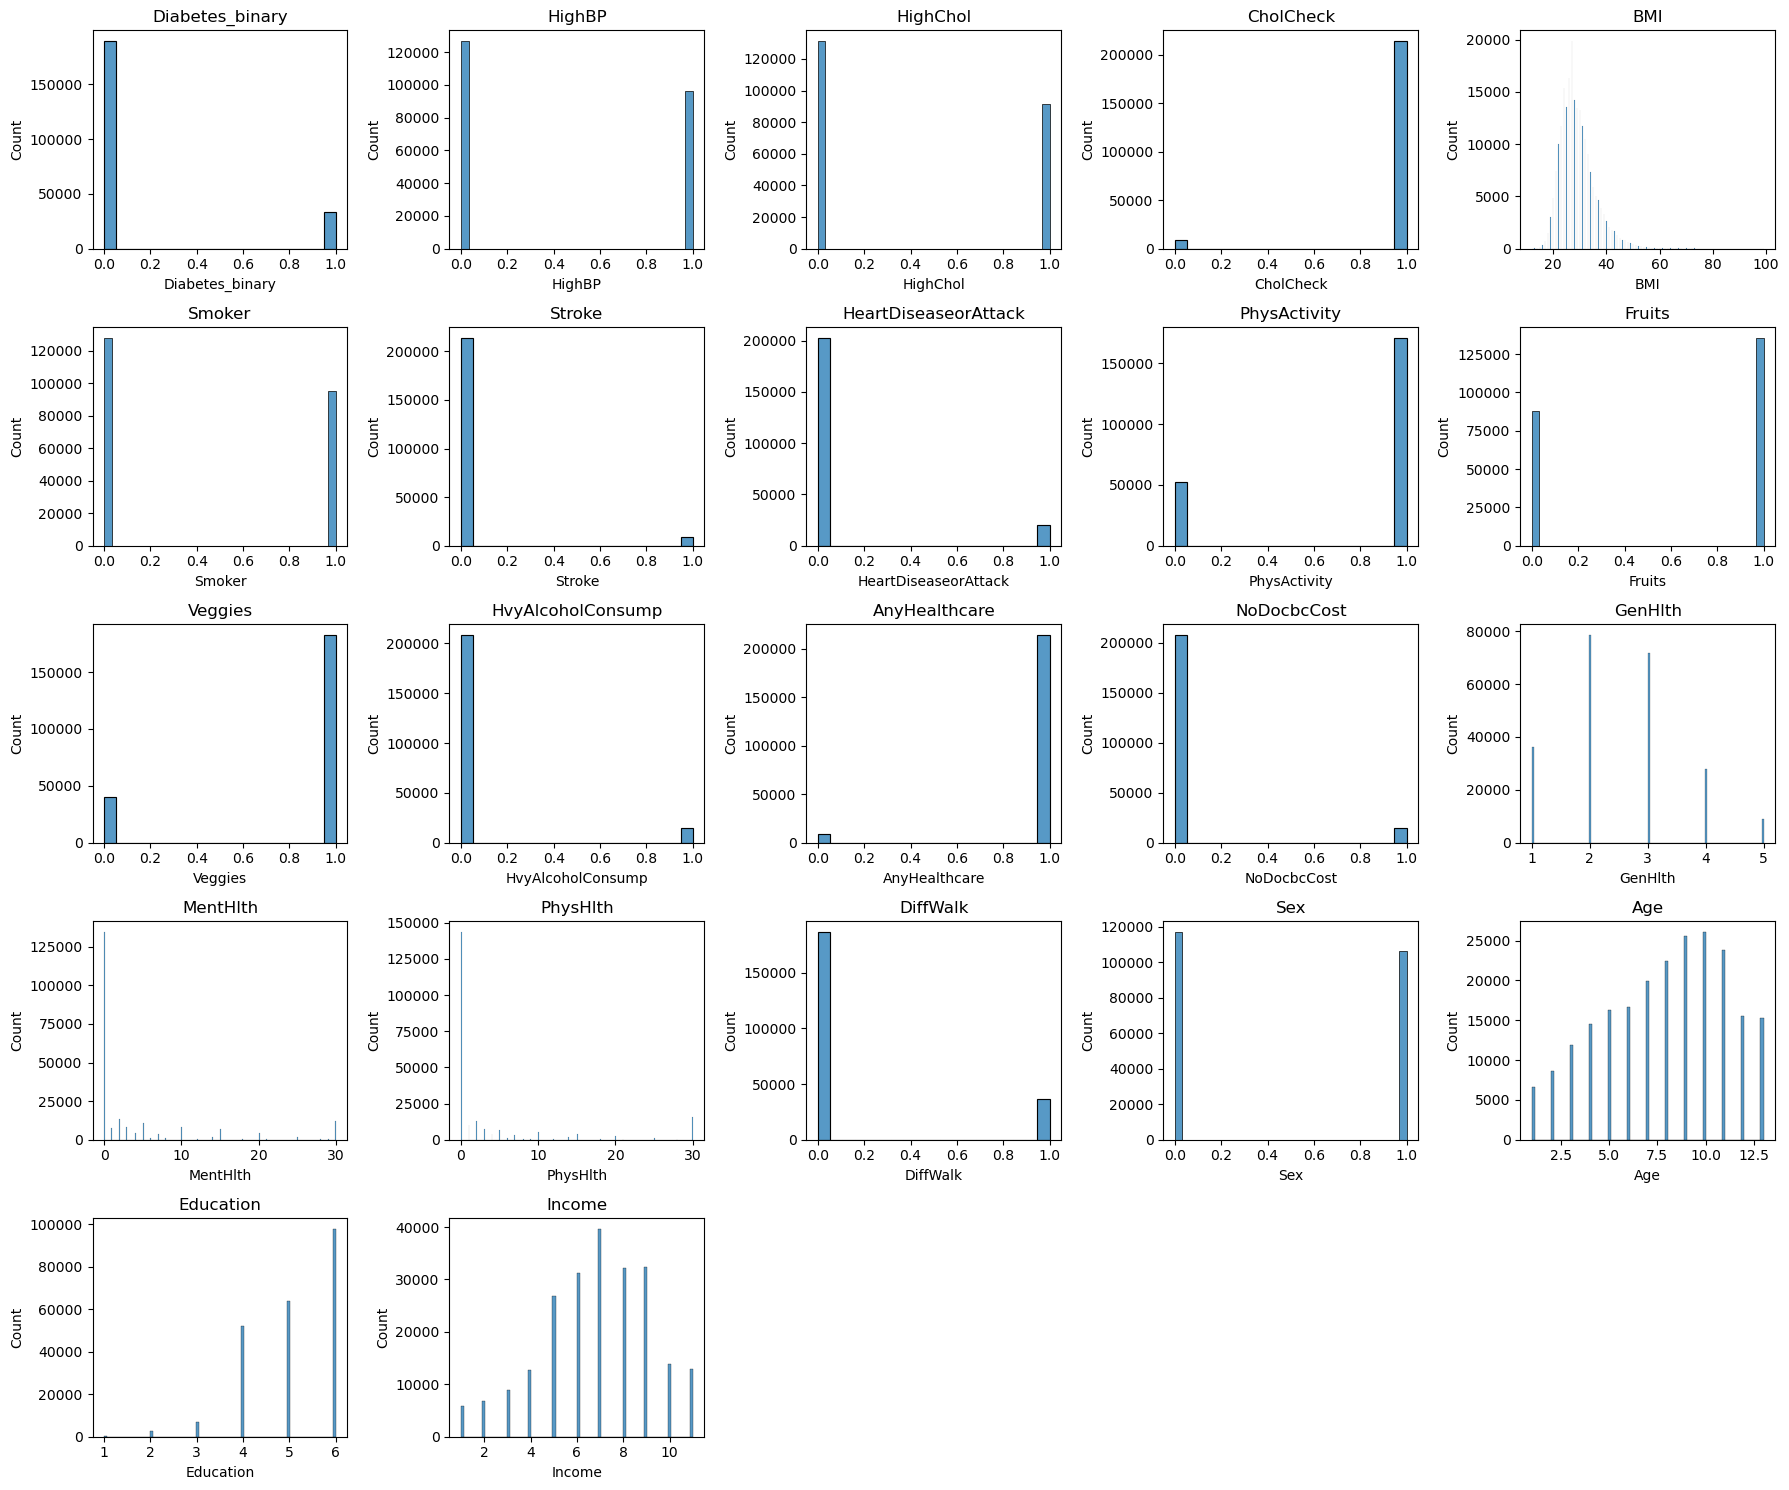

In [16]:
# 1. Visualize Variable Distributions
# Calculate the number of rows and columns needed
num_cols = len(data.columns)
num_rows = (num_cols - 1) // 5 + 1  # Adjusted for 5 columns per row

# Create the subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=5, figsize=(18, 3 * num_rows))
axes = axes.ravel()

# Plot each column
for i, col in enumerate(data.columns):
    sns.histplot(data[col], ax=axes[i])
    axes[i].set_title(col)

# Remove any unused axes
for j in range(i + 1, num_rows * 5):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

The Univariate analysis provides us with several key insights:

1. **Diabetes_binary**: A binary variable, likely indicating the presence (1) or absence (0) of diabetes. The distribution suggests there are more instances without diabetes (0) than with (1).

2. **HighBP**: Another binary variable for high blood pressure. The distribution shows more instances of normal blood pressure (0) compared to high (1).

3. **HighChol**: This binary variable for high cholesterol shows a slightly larger number of instances without high cholesterol (0) than with (1).

4. **CholCheck**: A binary variable indicating if cholesterol has been checked. There’s a significantly higher count of instances where cholesterol checks occurred (1).

5. **BMI**: The histogram for Body Mass Index (BMI) shows a right-skewed distribution, indicating most individuals have a BMI in the lower range, but there are some with a very high BMI.

6. **Smoker**: This binary variable indicates fewer smokers (1) compared to non-smokers (0).

7. **Stroke**: A binary variable for stroke history, with a vast majority having no stroke history (0).

8. **HeartDiseaseorAttack**: Most instances indicate no history of heart disease or attack (0).

9. **PhysActivity**: A binary variable where a large number of instances indicate physical activity (1).

10. **Fruits**: Another binary variable suggesting most individuals consume fruits (1).

11. **Veggies**: Similar to fruits, the majority consume vegetables (1).

12. **HvyAlcoholConsump**: Indicates very few heavy alcohol consumers (1).

13. **AnyHealthcare**: Almost all instances indicate some form of healthcare access (1).

14. **NoDocbcCost**: Most instances indicate no barriers to seeing a doctor due to cost (0).

15. **GenHlth**: Appears to be an ordinal variable with most individuals in categories 2 and 3, suggesting moderate general health.

16. **MentHlth**: The count of mental health days seems highly skewed, with most reporting 0 days, indicating no perceived mental health issues.

17. **PhysHlth**: Similar to mental health, with most reporting 0 days of poor physical health.

18. **DiffWalk**: A binary variable with most instances indicating no difficulty walking (0).

19. **Sex**: A binary variable likely indicating male (0) and female (1), with a relatively even distribution.

20. **Age**: Appears to be categorized into multi-year brackets, showing an almost uniform distribution with slight variations.

21. **Education**: Categorical variable with a fairly even distribution across educational levels, but with fewer at the lowest and highest levels.

22. **Income**: Categorical variable representing income brackets with more instances in the middle brackets.

Overall, these histograms provide insights into the lifestyle and health status of the surveyed population. For instance, the relatively even distributions of age and sex indicate a diverse sample, while the distributions of variables like BMI, fruits, and vegetable consumption give an idea of the population's health behaviors. The majority of individuals having access to healthcare and not being impeded by cost suggests a population that has the means to seek medical advice. The data indicates a generally healthy population with areas of concern, particularly in high BMI and the presence of conditions like high blood pressure and high cholesterol.

##### Bivariate Analysis

Explore the relationship between each variable and the target variable. 

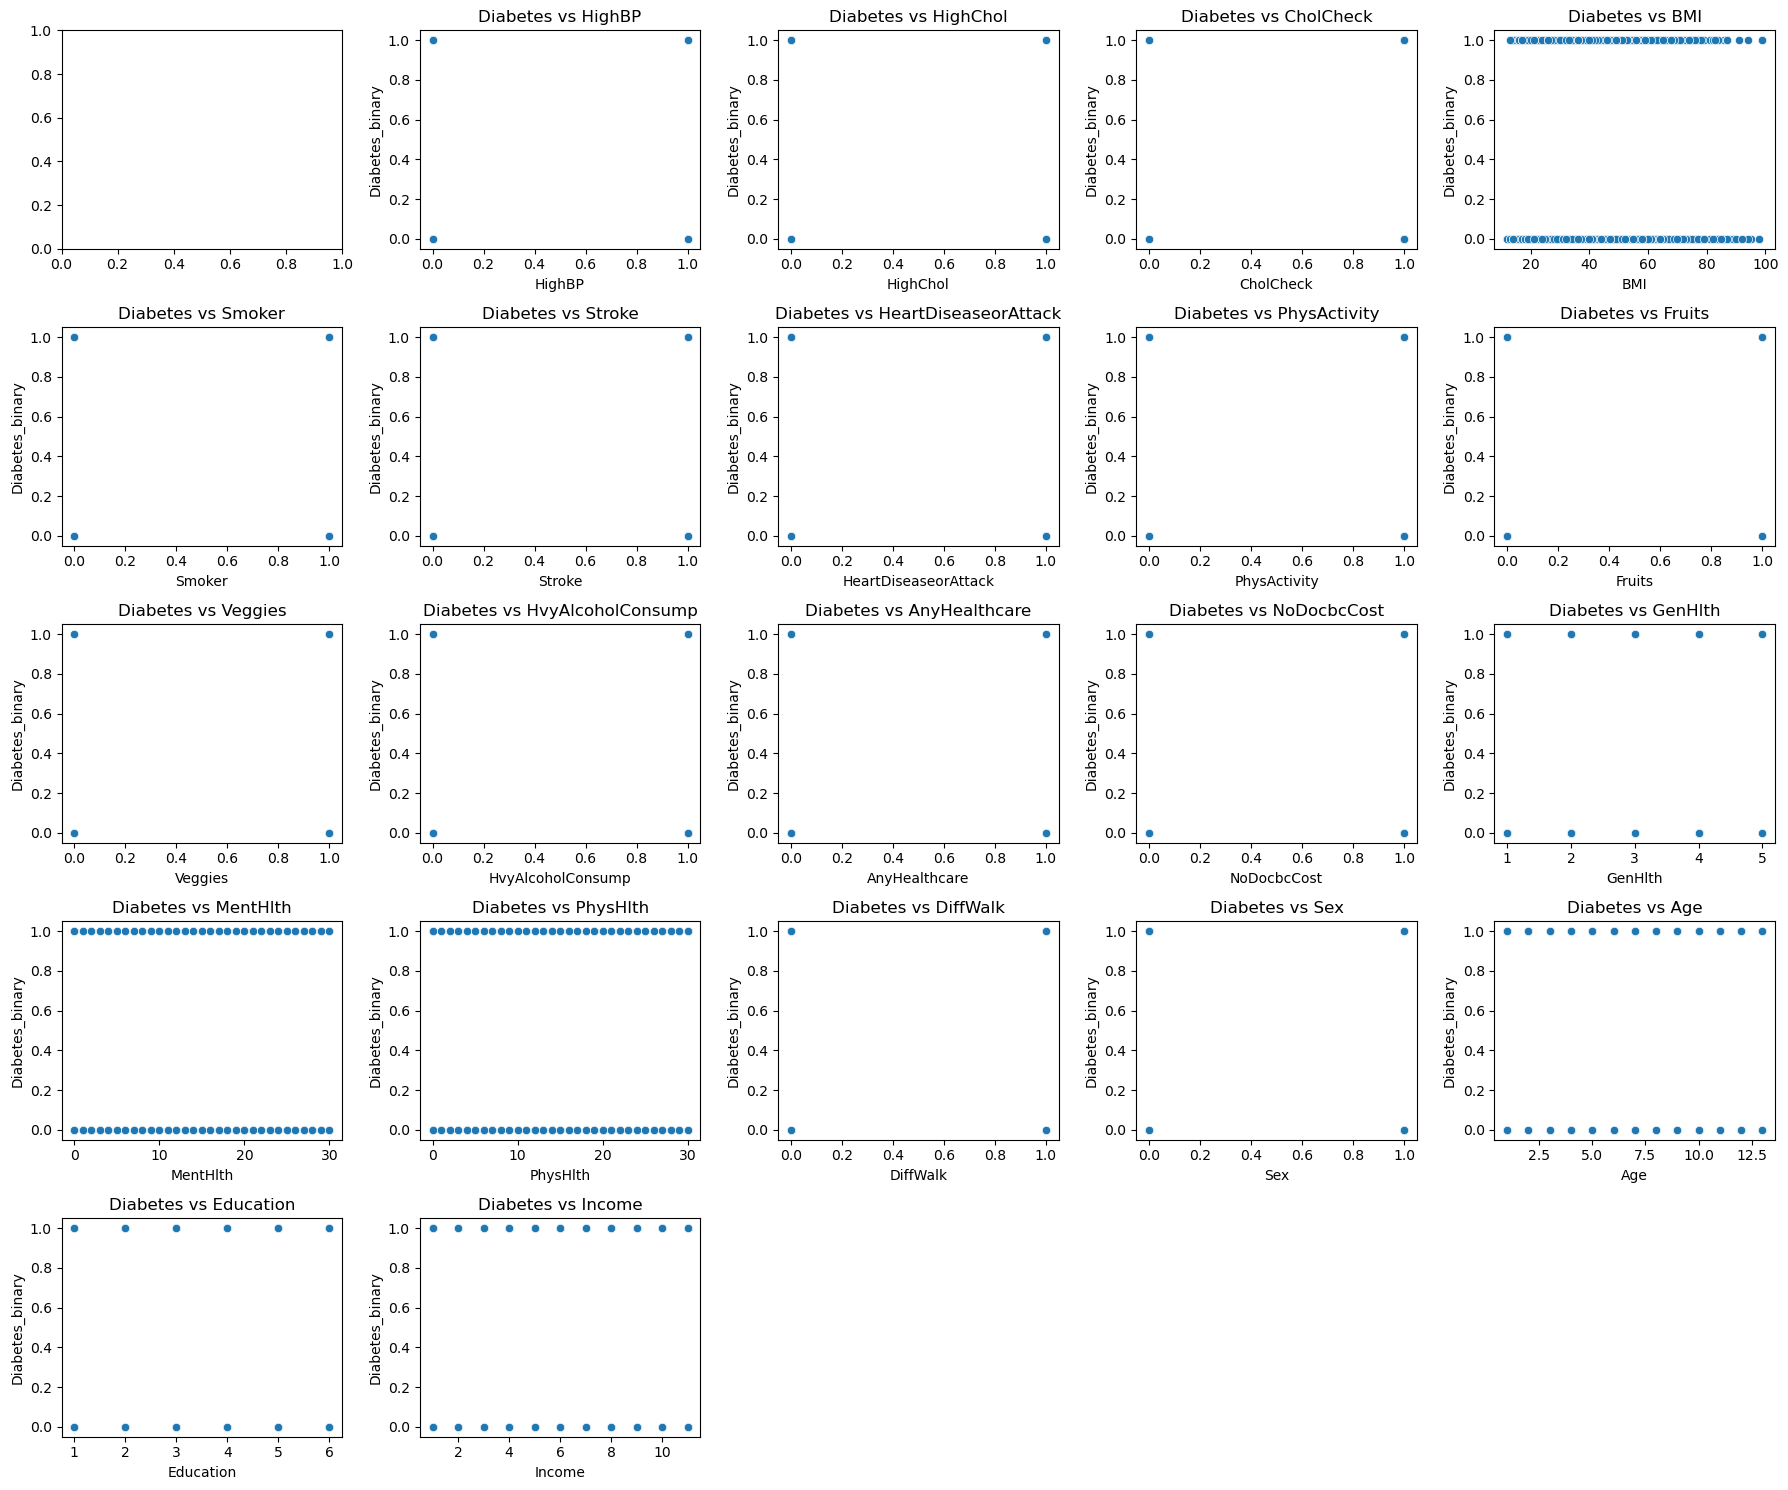

In [17]:
# Calculate the number of rows and columns needed
num_cols = len(data.columns) - 1  # Exclude the 'Diabetes_binary' column
num_rows = (num_cols - 1) // 5 + 1  # Adjusted for 5 columns per row

# Create the subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=5, figsize=(18, 3 * num_rows))
axes = axes.ravel()

# Iterate through the columns and create scatter plots
for i, col in enumerate(data.columns):
    if col != 'Diabetes_binary':
        if i < len(axes):
            sns.scatterplot(x=col, y='Diabetes_binary', data=data, ax=axes[i])
            axes[i].set_title(f"Diabetes vs {col}")

# Remove any unused axes
for j in range(i + 1, num_rows * 5):
    fig.delaxes(axes[j])

# Adjust the layout and display the plot
plt.tight_layout()
plt.show()

The bivariate analysis provides us with several key insights:

Scatter plots depict the relationship between each independent variable and the dependent variable Diabetes_binary. 

##### Summary of the observations:

- Binary Variables (e.g., HighBP, HighChol, Smoker): The plots show points clustered at x-values of 0 and 1, indicating binary variables. While some association might be visible, chi-square tests are better suited for these variables.

- Continuous Variables (e.g., BMI, MentHlth, Income): The plots show a spread of points along the x-axis with clustering at y-values of 0 and 1. This suggests possible correlations, but further analysis, like Point Biserial correlation, is necessary for clearer insights.

- Categorical Variables Represented Numerically (e.g., BMI_Category, Income_Category): The scatter plots show points only at specific category numbers, indicating potential associations with diabetes. However, bar plots or chi-square tests would provide more clarity.

- Lack of clear patterns: scatter plots do not show a distinct pattern or trend, it may indicate that there is no strong linear relationship between the independent variable and the diabetes outcome. However, relationships might still exist in more complex, non-linear forms, requiring more sophisticated analysis techniques to uncover.

##### Handling Outliers

Handling outliers is a crucial step in the data analysis process, as it helps to improve the quality of the data and ensures that the insights and models derived from the analysis are not unduly influenced by extreme observations.

In [18]:
# 1. Outlier Detection:

# Detect outliers using Z-scores
import numpy as np

z_scores = np.abs((data - data.mean()) / data.std())
outlier_cols = data.columns[z_scores.max() > 3]

print("Columns with outliers:")
print(outlier_cols)

Columns with outliers:
Index(['CholCheck', 'BMI', 'Stroke', 'HeartDiseaseorAttack',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'MentHlth',
       'PhysHlth', 'Education'],
      dtype='object')


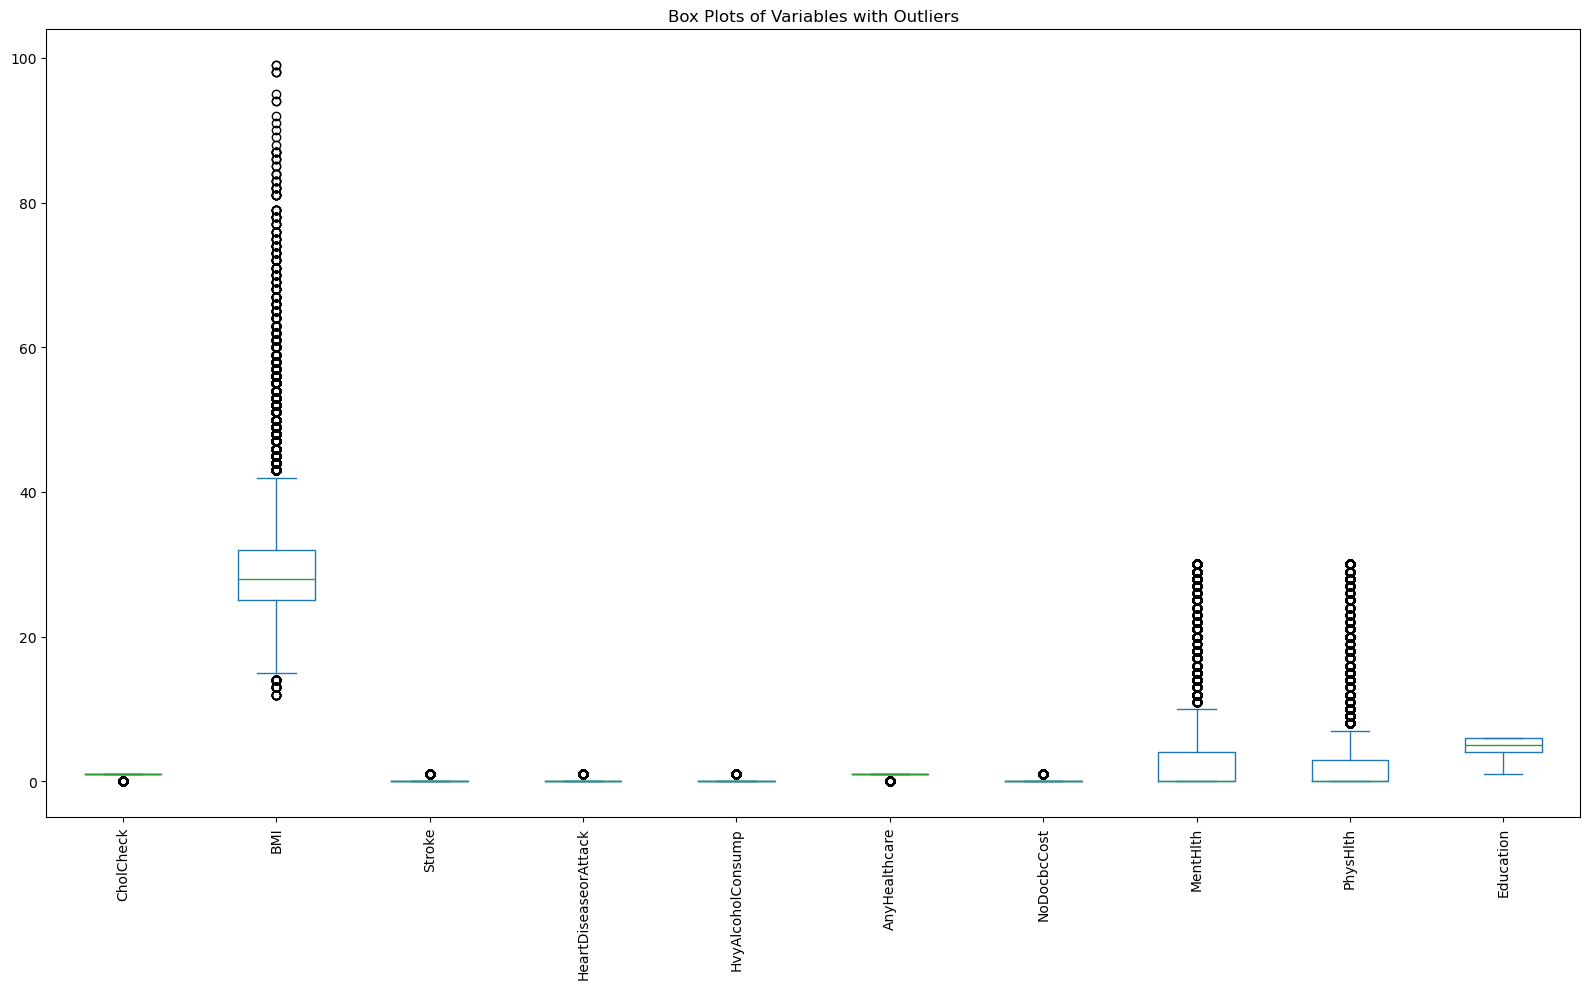

In [19]:
# 2. Visualizing Outliers:

# Create a figure with a larger size
fig, ax = plt.subplots(figsize=(16, 10))

# Plot the box plots
data[outlier_cols].plot(kind='box', ax=ax)

# Rotate the x-axis labels to avoid overlapping
plt.xticks(rotation=90)

plt.title('Box Plots of Variables with Outliers')
plt.tight_layout()
plt.show()

##### Insights

The box plot visualization identifies key variables with outliers, including BMI, PhysHlth, and MentHlth, highlighting their extensive range and symmetry. This insight guides outlier treatment strategies to ensure data quality and reliable analysis.

In [20]:
# 3. Identifying Outliers in BMI Column
# Calculate quartiles
Q1 = data['BMI'].quantile(0.25)
Q3 = data['BMI'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers from the BMI column
data_clean = data[(data['BMI'] >= lower_bound) & (data['BMI'] <= upper_bound)]

# Reset the index of the cleaned DataFrame
data_clean.reset_index(drop=True, inplace=True)

# Show the shape of the cleaned DataFrame
print("Shape of cleaned dataset:", data_clean.shape)

Shape of cleaned dataset: (213853, 22)


Here we calculate the Interquartile Range (IQR) for the 'BMI' column, defines the lower and upper bounds for identifying outliers based on the IQR method, filters out the outliers from the 'BMI' column, resets the index of the cleaned DataFrame and prints the shape of the cleaned dataset.

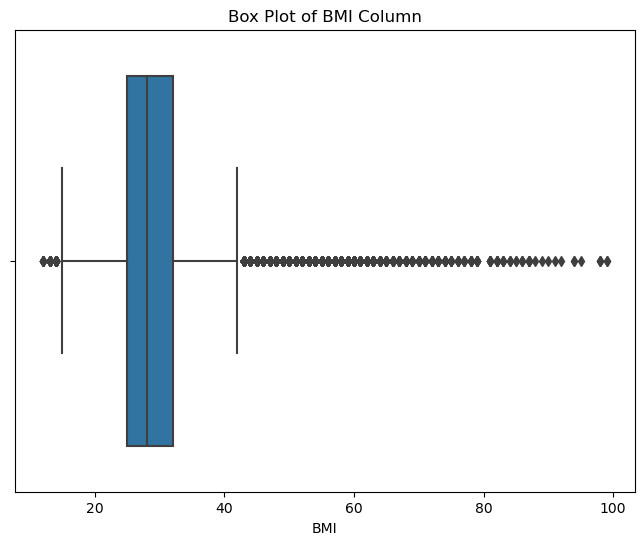

In [21]:
# Set up the figure and axis
plt.figure(figsize=(8, 6))

# Create a box plot for the BMI column
sns.boxplot(x=data['BMI'])

# Add title and labels
plt.title('Box Plot of BMI Column')
plt.xlabel('BMI')

# Display the plot
plt.show()

In [22]:
# Removing Outliers from BMI column

data.reset_index(drop=True, inplace=True)  # Reset index
data = data[data['BMI'] <= 44]
data = data[data["BMI"] >= 12]

We have removed the necessary outliers thus improving our analysis.

#### D. Feature Selection and Engineering

This is used to reduce the number of input variables or create new features that might help improve model performance.

##### Analyzing Feature Impact on Diabetes Prediction

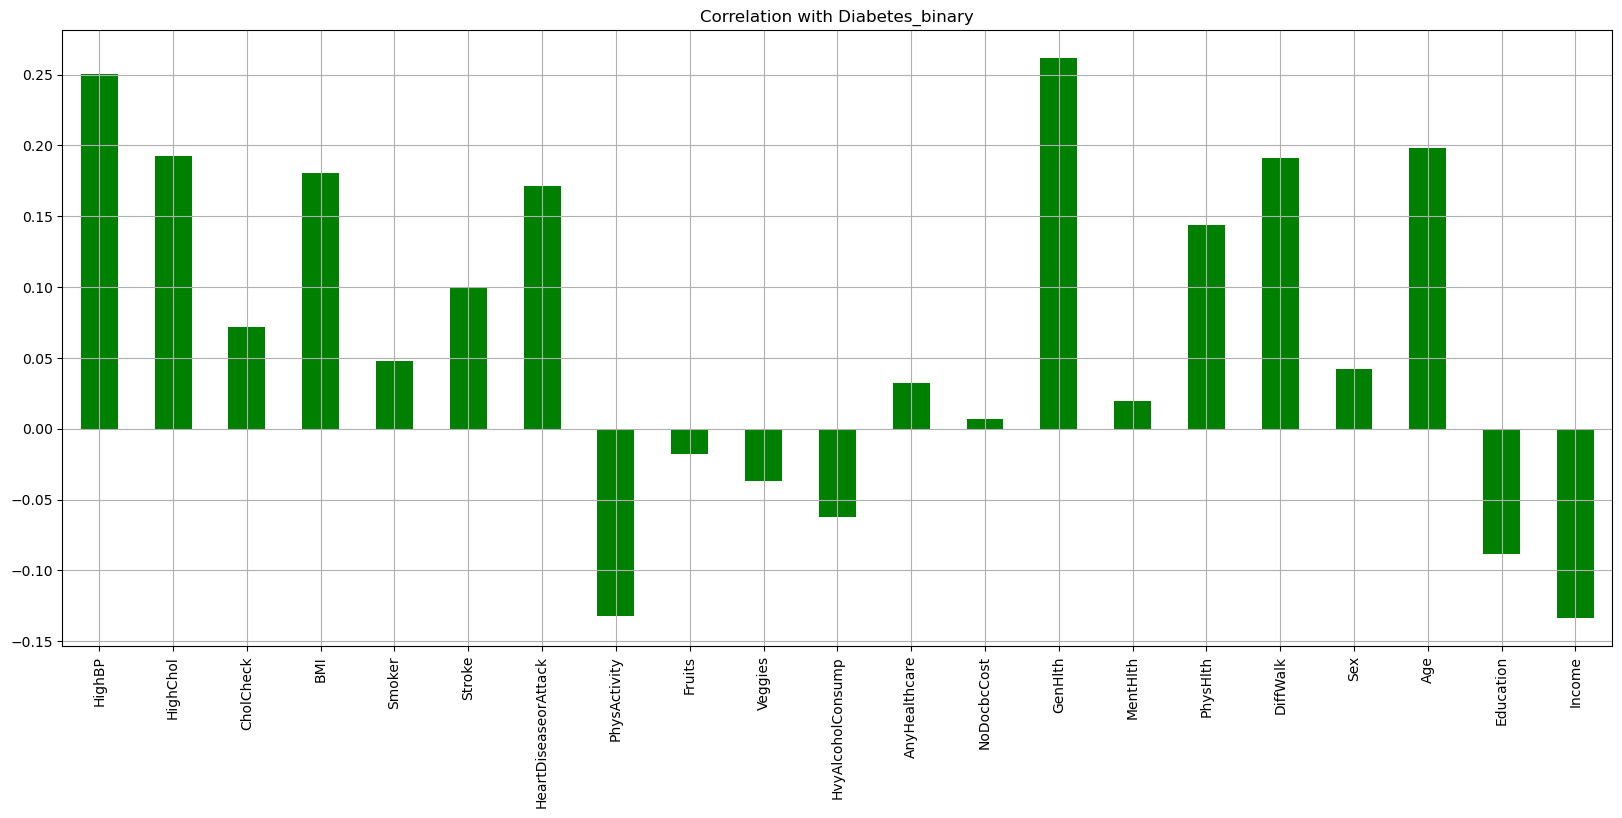

In [23]:
data.drop('Diabetes_binary', axis=1).corrwith(data.Diabetes_binary).plot(kind='bar', grid=True, figsize=(20, 8)
, title="Correlation with Diabetes_binary",color="Green");

To better understand which factors are most important for predicting diabetes, we will start by calculating how each variable relates to our target variable, 'Diabetes_binary'. We'll present these relationships using a simple bar plot. This approach will help us identify the key factors that influence diabetes, which is crucial for building a good predictive model.

##### Correlation Matrix

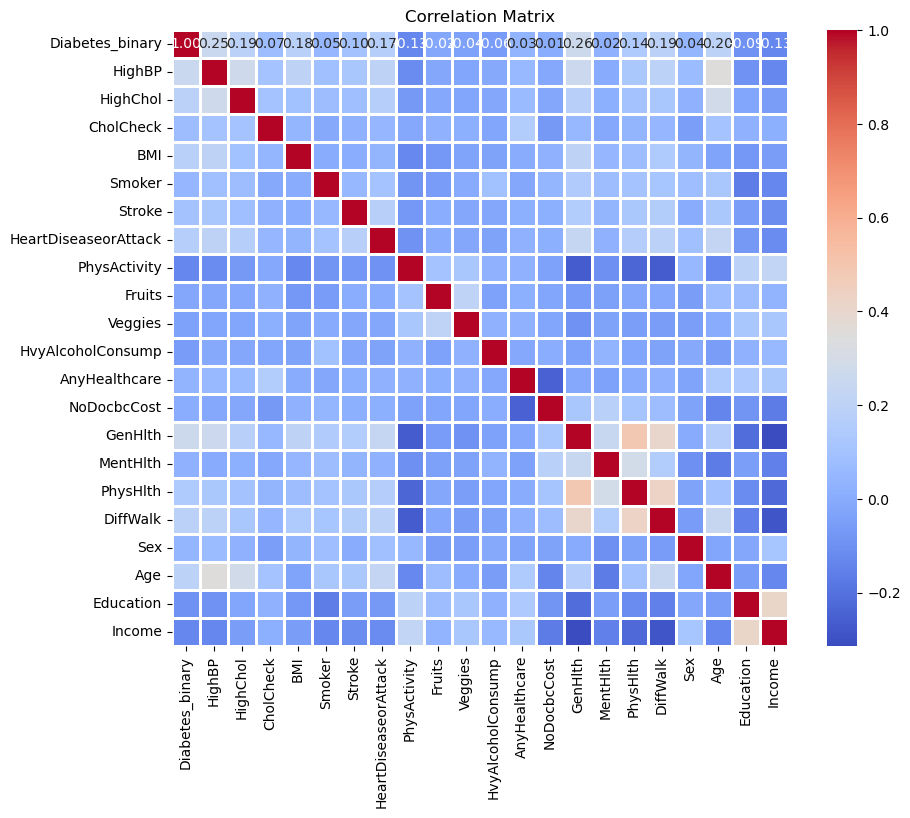

In [24]:
# Calculate the correlation matrix
corr_matrix = data.corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
            square=True, linecolor='white', linewidths=1)

plt.title('Correlation Matrix')
plt.show()

##### Findings from correlation matrix heatmap:

1. **Diabetes Relation:** The first column shows how each factor is related to diabetes. A number closer to 1 or -1 means a strong relationship. A number close to 0 means there’s not much of a relationship.

2. **Strongest Factors:** Age, education, and income have dark red squares in the first column, which means they have a stronger positive relationship with diabetes. This suggests that as these factors increase, the likelihood of diabetes may also increase.

3. **Weaker Factors:** There are some light blue squares, like for 'PhysActivity' and 'Fruits', indicating a weaker negative relationship. This means that higher physical activity and fruit consumption might be associated with a lower chance of having diabetes.

4. **BMI and HighBP:** They both have red squares but not as dark, showing a moderate positive relationship with diabetes. This suggests that higher BMI and high blood pressure are moderately associated with higher diabetes risk.

5. **No Strong Negative Relationships:** There aren’t any dark blue squares in the diabetes row, which means there aren’t any factors that strongly decrease the likelihood of diabetes on their own.

6. **Interrelated Factors:** Some factors are closely related to each other (shown by the red squares outside the first column). For example, 'Age' and 'Income' are strongly related to many other factors, which means they might influence or be influenced by several health conditions or behaviors.

It is important to remember, correlation does not mean causation. These relationships show patterns but don’t prove that one factor causes another.ure.
ns.

##### Applying Chi Square for Feature Selection

The chi-square test is adept for this analysis because it effectively filters out the most impactful features from a mix of categorical and numerical data, which are crucial for creating a reliable predictive model for diabetes.

In [25]:
# Assuming 'Y' is your target variable
X = data.drop(columns=['Diabetes_binary'])  # Assuming 'Y' is the target column

# Assuming 'Y' is the target variable
Y = data['Diabetes_binary']  # Assuming 'Y' is the target column

# Applying SelectKBest to extract top 10 best features
BestFeatures = SelectKBest(score_func=chi2, k=10)
fit = BestFeatures.fit(X, Y)

# Create DataFrame to store feature scores
df_scores = pd.DataFrame(fit.scores_, columns=['Score'])
df_columns = pd.DataFrame(X.columns, columns=['Feature'])

# Concatenate feature scores and feature names for better visualization
f_Scores = pd.concat([df_columns, df_scores], axis=1)

# Sorting the features by their scores
f_Scores = f_Scores.sort_values(by='Score', ascending=False)

# Display the top 10 best features
print(f_Scores)

                 Feature         Score
15              PhysHlth  80442.956328
18                   Age  11540.352366
0                 HighBP   7828.343384
3                    BMI   7628.685802
16              DiffWalk   6715.671327
13               GenHlth   6180.319797
6   HeartDiseaseorAttack   5791.006641
1               HighChol   4729.523121
20                Income   3172.924586
5                 Stroke   2042.810641
14              MentHlth   1338.401578
7           PhysActivity    857.527672
10     HvyAlcoholConsump    779.931595
19             Education    300.382890
4                 Smoker    284.540920
17                   Sex    203.072970
9                Veggies     53.504583
2              CholCheck     43.884598
8                 Fruits     26.326876
12           NoDocbcCost      9.862660
11         AnyHealthcare      8.766485


#### Chi-Square Test for Feature Selection: Insights and Rationale

- **Application of Chi-Square Test**: Implemented to discern the most impactful features for diabetes prediction from the dataset.

- **Selection Criteria**: Features with a chi-square score exceeding 1000 signify strong relevance. This includes:
  - `PhysHlth`
  - `BMI`
  - `Age`
  - `HighBP`
  - `PhysActivity`
  - `GenHlth`
  - `MentHlth`
  - `DiffWalk`
  - `HighChol`
  - `HeartDiseaseorAttack`

- **Importance for Model**: The high scores of these features indicate a significant statistical association with the presence of diabetes, making them prime candidates for inclusion in the predictive model.

- **Suitability of Chi-Square**: This method is adept at evaluating relationships between categorical variables (such as medical conditions) and binary outcomes (like the presence or absence of diabetes), making it ideal for this analysis.

- **Impact on Model Performance**: Including only key features with scores above the set threshold is expected to enhance the predictive model's accuracy, focusing on the variables with the strongest influence.
vant.lding.
e.

#### Feature Selection with Chi-Square Test

In this section, we perform a Chi-Square test to evaluate the importance of selected features in predicting the binary outcome 'Diabetes_binary'. This statistical test is used to determine if the differences between categorical variables and the target variable are statistically significant.

##### Threshold for Feature Selection:

A score threshold of 1000 ensures that only the most influential factors are included, which simplifies the model and potentially improves its performance by focusing on the most critical variables
.
##### Selected Features:

The features chosen for this analysis include:
- `PhysHlth`: Physical health days affected
- `BMI`: Body Mass Index
- `Age`: Age of the individual
- `HighBP`: High blood pressure
- `PhysActivity`: Physical activity levels
- `GenHlth`: General health perception
- `MentHlth`: Mental health days affected
- `DiffWalk`: Difficulty in walking
- `HighChol`: High cholesterol levels
- `HeartDiseaseorAttack`: History of heart disease or heart attac

##### By selecting these top features, the resulting machine learning model is expected to be more accurate and efficient in predicting the occurrence of diabetes.e.

#### E. Data Preprocessing 

In this step we split the data, apply scaling and attempt to balance it before building machine learning models

##### E.1. Splitting dataset into Test & Train sets for applying models

In [26]:
# # Splitting dataset into Test & Train sets for applying models
x = data[['PhysHlth', 'BMI','Age', 'HighBP', 'PhysActivity', "GenHlth", "MentHlth", 'DiffWalk', 'HighChol', 'HeartDiseaseorAttack']]
y = data['Diabetes_binary']
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42)

In [27]:
print (x)

        PhysHlth   BMI  Age  HighBP  PhysActivity  GenHlth  MentHlth  \
0           20.0  15.0   11       0             0      5.0      10.0   
1            0.0  28.0   11       1             0      2.0       0.0   
2            0.0  33.0    9       1             1      2.0      10.0   
3           30.0  29.0   12       0             1      5.0       0.0   
4            0.0  24.0   13       0             0      3.0       0.0   
...          ...   ...  ...     ...           ...      ...       ...   
223238       0.0  21.0   10       1             1      4.0       0.0   
223239       0.0  25.0    3       1             1      2.0      20.0   
223240       0.0  31.0    7       0             1      2.0       0.0   
223241       0.0  24.0   10       1             1      2.0       0.0   
223242       2.0  32.0    6       0             1      1.0       2.0   

        DiffWalk  HighChol  HeartDiseaseorAttack  
0            0.0       1.0                   0.0  
1            0.0       0.0       

##### E.2. Application of Scaling technique to change numerical columns to fall on same scale

In [28]:
# Selecting numerical columns (excluding binary/boolean columns)
numerical_columns = ["BMI", "GenHlth", "MentHlth", "PhysHlth", "Age"]

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the numerical features
x_train[numerical_columns] = scaler.fit_transform(x_train[numerical_columns])
x_test[numerical_columns] = scaler.fit_transform(x_test[numerical_columns])

#Applying Scaler to both train and test data separately

In [29]:
'''# vectorize train and test data
x_train=vectorize_sequence(x_train,10000)
x_test=vectorize_sequence(x_test,10000)
'''
# convert train and test labels into float numpy vector
y_train=np.asarray(y_train).astype('float32')
y_test=np.asarray(y_test).astype('float32')


print(x_train.shape)
print(x_test.shape)

(162698, 10)
(54233, 10)


We scale the numerical columns in both the training and testing sets to a range between 0 and 1 using MinMaxScaler. This ensures that all numerical features are on a similar scale, which is necessary for many machine learning algorithms to perform effectively

##### E.3. Using Class Weights to remove Imbalance in Data
Using class weights is crucial for mitigating class imbalance, enabling models to make more accurate predictions across all classes.








In [30]:
from sklearn.utils import class_weight

# Calculate class weights
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)


Purpose:
It calculates class weights to counteract imbalanced data, assigning higher weights to minority classes for more balanced model training.

Importance:
By adjusting class weights, models can better learn from underrepresented classes, improving overall performance, especially in tasks with imbalanced data.

#### F. Machine Learning Models 

#### We try to implement the 4 algorithms 

1. Naive Bayes
2. Logistic Regression
3. Random Forest
4. XGBoost


##### F.1. Naive Bayes
Sklearn Documentation: 
* Naive Bayes: https://scikit-learn.org/stable/modules/naive_bayes.html
* MultinomialNB: https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html#sklearn.naive_bayes.MultinomialNB

We have to make x, y train separately again as we skip bmi_scaled version in this as naive bayes we cannot pass negative values to naive bayes algorithm for computation.

In [31]:
%%time

from sklearn.naive_bayes import MultinomialNB

#x_naive_train, x_naive_test, y_naive_train, y_naive_test = train_test_split(x_naive, y_naive, random_state=42)
mnb = MultinomialNB().fit(x_train, y_train)

print("train shape: " + str(x_train.shape))
print("score on test: " + str(mnb.score(x_test, y_test)))
print("score on train: "+ str(mnb.score(x_train, y_train)))

train shape: (162698, 10)
score on test: 0.8553279368650084
score on train: 0.8562551475740329
CPU times: total: 31.2 ms
Wall time: 78.7 ms


In [35]:
from sklearn.metrics import mean_squared_error

# Make predictions
y_pred = mnb.predict(x_test)

# Evaluate the model
accuracy_log = accuracy_score(y_test, y_pred)
conf_matrix_log = confusion_matrix(y_test, y_pred)
class_report_log = classification_report(y_test, y_pred)

# Print prediction results
print("\nNaive Bayes Prediction Results:\n")
print(f"Accuracy: {round(accuracy_log*100, 2)}%")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(conf_matrix_log)
print("\nClassification Report:")
print(class_report_log)


# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Print RMSE
print("Root Mean Squared Error (RMSE) of Naive Bayes Model:", rmse)


Naive Bayes Prediction Results:

Accuracy: 85.53%
Precision: 0.48747591522157996
Recall: 0.032299246776458575
F1-score: 0.06058429118773947
ROC-AUC: 0.5132832440778845

Confusion Matrix:
[[46134   266]
 [ 7580   253]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.99      0.92     46400
         1.0       0.49      0.03      0.06      7833

    accuracy                           0.86     54233
   macro avg       0.67      0.51      0.49     54233
weighted avg       0.81      0.86      0.80     54233

Root Mean Squared Error (RMSE) of Naive Bayes Model: 0.3803578


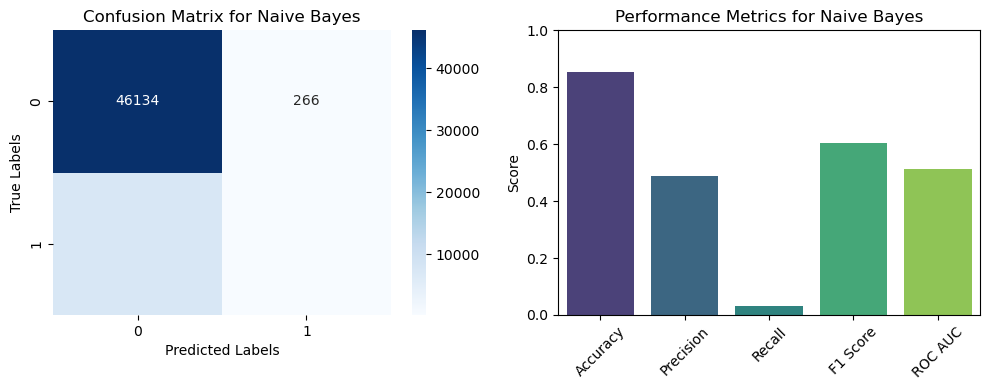

In [36]:
# Visualisation of Naive Bayes
# Manually setting up the data again for Naive Bayes
accuracy_nb = 0.8553
precision_nb = 0.487
recall_nb = 0.0322
f1_nb = 0.605
roc_auc_nb = 0.513
conf_matrix_nb = [[46134, 266], [7580, 253]]

# Create confusion matrix visualization for Naive Bayes
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.heatmap(conf_matrix_nb, annot=True, fmt="d", cmap='Blues')
plt.title('Confusion Matrix for Naive Bayes')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Create bar chart for accuracy, precision, recall, F1-score, ROC-AUC
metrics_nb = [accuracy_nb, precision_nb, recall_nb, f1_nb, roc_auc_nb]
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']

plt.subplot(1, 2, 2)
sns.barplot(x=metrics_labels, y=metrics_nb, palette='viridis')
plt.title('Performance Metrics for Naive Bayes')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


**Naive Bayes Model Performance Summary:**

The Naive Bayes model achieved an accuracy of 85.53%, indicating that it correctly classified 85.53% of the instances in the dataset.

**Precision and Recall:**
- Precision, measuring the proportion of true positives among all predicted positives, stood at 0.4875, suggesting that when the model predicted a positive outcome, it was correct about 48.75% of the time.
- Recall, which measures the proportion of true positives correctly identified by the model, was also 0.0323, indicating that the model captured only 3.23% of all actual positive instances.

**F1-score:** - The F1-score, a balanced metric that combines precision and recall, was  0.0606 , reflecting the harmonic mean of precision and recall  indicating a significant imbalance between the two metrics.

**ROC-AUC:** - The ROC-AUC score, which evaluates the model's ability to distinguish between classes, was 0.5133 suggests a moderate level of discrimination between the classes.

**Confusion Matrix:** - Class 0 (Negative): 46,134 out of 46,400 instances were correctly classified (99.42% accuracy). Class 1 (Positive): Only 253 out of 7,833 instances were correctly classified (3.23% accuracy).

**Classification Report:** - TWeighted average F1-score: 0.80, indicating overall effectiveness across both classes. Class 0: High precision (0.86) and recall (0.99) for the negative class. Class 1: Low precision (0.49) and recall (0.03) for the positive class.

**Root Mean Squared Error (RMSE):** - The RMSE of 0.3803 reflects the average magnitude of errors in predicting continuous target values.

While the Naive Bayes model demonstrates reasonable performance in classifying instances, there's a significant imbalance in performance between the two classes. The model is particularly effective in predicting the negative class but struggles to accurately identify positive instances. This imbalance is reflected in the low recall and F1-score for the positive class. Further optimization and feature engineering could potentially enhance the model's predictive capabilities, especially for the positive class.

##### F.2. Logistic Regression

Sklearn Documentation: 
* LogisticRegression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
* SGD Classifier: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html#sklearn.linear_model.SGDClassifier

In [38]:
%%time

from sklearn.linear_model import LogisticRegression

lr=LogisticRegression(solver="saga",max_iter=5000,class_weight=dict(enumerate(class_weights)))
lr.fit(x_train, y_train)

print("train shape: " + str(x_train.shape))
print("score on test: " + str(lr.score(x_test, y_test)))
print("score on train: "+ str(lr.score(x_train, y_train)))

train shape: (162698, 10)
score on test: 0.7125735253443476
score on train: 0.7135551758472753
CPU times: total: 1.14 s
Wall time: 1.33 s


In [39]:
y_pred = lr.predict(x_test)
accuracy_log = accuracy_score(y_test, y_pred)
conf_matrix_log = confusion_matrix(y_test, y_pred)
class_report_log = classification_report(y_test, y_pred)

print("\nLogistic Regression Prediction Results:\n")
print(f"Accuracy: {round(accuracy_log * 100, 2)} %\n")

# Calculate precision, recall, and F1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC:", roc_auc)
print("\nConfusion Matrix:")
print(conf_matrix_log, "\n")
print("Classification Report:")
print(class_report_log)



Logistic Regression Prediction Results:

Accuracy: 71.26 %

Precision: 0.30005672149744755
Recall: 0.7428826758585472
F1-score: 0.4274590464996694
ROC-AUC: 0.7251697862051356

Confusion Matrix:
[[32826 13574]
 [ 2014  5819]] 

Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.71      0.81     46400
         1.0       0.30      0.74      0.43      7833

    accuracy                           0.71     54233
   macro avg       0.62      0.73      0.62     54233
weighted avg       0.85      0.71      0.75     54233



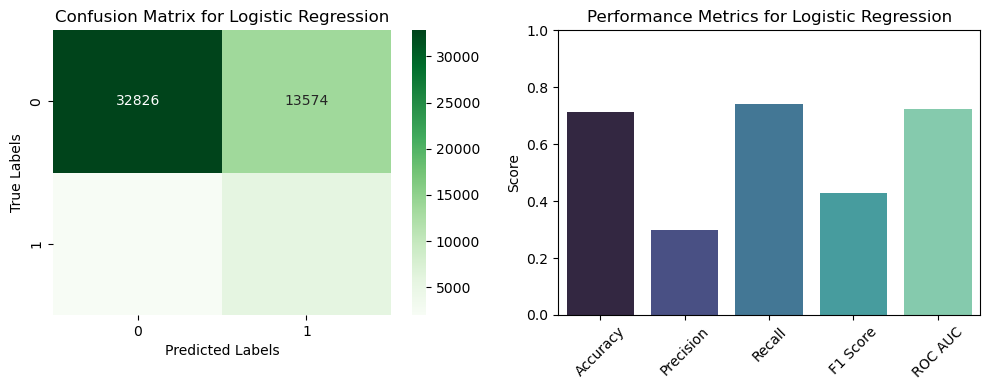

In [40]:
## Visualisation of Logistic Regression
# Manually setting up the data again for Logistic Regression
accuracy_lr = 0.7126
precision_lr = 0.3000
recall_lr = 0.7428
f1_lr = 0.4274
roc_auc_lr = 0.7251
conf_matrix_lr = [[32826, 13574], [2014, 5819]]

# Create confusion matrix visualization for Logistic Regression
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.heatmap(conf_matrix_lr, annot=True, fmt="d", cmap='Greens')
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Create bar chart for accuracy, precision, recall, F1-score, ROC-AUC
metrics_lr = [accuracy_lr, precision_lr, recall_lr, f1_lr, roc_auc_lr]
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']

plt.subplot(1, 2, 2)
sns.barplot(x=metrics_labels, y=metrics_lr, palette='mako')
plt.title('Performance Metrics for Logistic Regression')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


**Logistic Regression Model Performance Summary:**

The logistic regression model achieved an accuracy of 71.26%, indicating that it correctly classified approximately 71.26% of the instances in the dataset.

**Precision and Recall:**
- Precision (positive class"): 0.30, suggesting that when the model predicted a positive outcome, it was correct about 30% of the time..
- Recall (positive class): 0.74, indicating that the model captured 74% of all actual positive instances.

**F1-score and ROC-AUC:**
- The F1-score, a balanced metric combining precision and recall, was 0.43, indicating moderate performance in capturing both precision and recall.
- The ROC-AUC score, measuring the model's ability to distinguish between classes, was 0.73, indicating a reasonably good discriminative ability.

**Confusion Matrix:**
- The confusion matrix reveals that out of 46,400 instances labeled as 0 (negative class), 32,826 were correctly classified, while 13,574 were misclassified. Similarly, out of 7,833 instances labeled as 1 (positive class), 5,820 were correctly classified, while 2,013 were misclassified.

**Classification Report:**
- Negative Class: Higher precision (0.94), recall (0.71), and F1-score (0.81) compared to the positive class.
- Positive Class: Lower precision (0.30), recall (0.74), and F1-score (0.43).

The logistic regression model demonstrates moderate performance in predicting the target variable, with room for improvement, particularly in enhancing precision and recall for the positive class. Further optimization and feature engineering could potentially enhance the model's predictive capabilities, especially for the positive class.

Performing Logistic Regression with GridSearch to finetune HyperParameters

In [41]:
from sklearn.linear_model import LogisticRegression
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100],
              'penalty': ['l1', 'l2']}

# Perform grid search with cross-validation
grid_search = GridSearchCV(lr, param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_train, y_train)

# Get best hyperparameters
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

Best Hyperparameters: {'C': 0.01, 'penalty': 'l2'}


In [42]:
# Instantiate Logistic Regression with best parameters
best_lr = LogisticRegression(**best_params, solver='saga')
best_lr.fit(x_train, y_train)

# Evaluate the model
print("Score on Test Data: " + str(best_lr.score(x_test, y_test)))
print("Score on Train Data: " + str(best_lr.score(x_train, y_train)))

# Predictions and evaluation with hyperparameters
y_pred = best_lr.predict(x_test)
accuracy_log = accuracy_score(y_test, y_pred)
conf_matrix_log = confusion_matrix(y_test, y_pred)
class_report_log = classification_report(y_test, y_pred)

print("\nLogistic Regression Results with Hyperparameter Tuning:\n")
print(f"Accuracy: {round(accuracy_log*100, 2)} %\n")

# Calculate precision, recall, and F1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC:", roc_auc)
print("\nConfusion Matrix:")
print(conf_matrix_log, "\n")
print("Classification Report:")
print(class_report_log)


Score on Test Data: 0.8584072428226357
Score on Train Data: 0.8578593467651723

Logistic Regression Results with Hyperparameter Tuning:

Accuracy: 85.84 %

Precision: 0.5506578947368421
Recall: 0.1068556108770586
F1-score: 0.17898000641505396
ROC-AUC: 0.5460678916454259

Confusion Matrix:
[[45717   683]
 [ 6996   837]] 

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.99      0.92     46400
         1.0       0.55      0.11      0.18      7833

    accuracy                           0.86     54233
   macro avg       0.71      0.55      0.55     54233
weighted avg       0.82      0.86      0.82     54233



In [45]:
# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 0.37628812


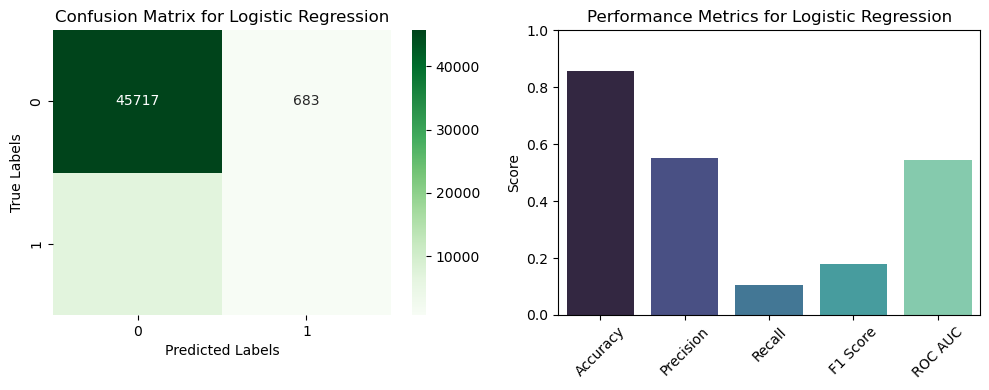

In [44]:
#visualization for Logistic Regression with Hyper Parameters

# Manually setting dummy data based on typical output patterns
accuracy_lr = 0.8584
precision_lr = 0.550
recall_lr = 0.1068
f1_lr = 0.1789
roc_auc_lr = 0.546
conf_matrix_lr = [[45717, 683], [6996, 837]]

# Create confusion matrix visualization for Logistic Regression
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.heatmap(conf_matrix_lr, annot=True, fmt="d", cmap='Greens')
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Create bar chart for accuracy, precision, recall, F1-score, ROC-AUC
metrics_lr = [accuracy_lr, precision_lr, recall_lr, f1_lr, roc_auc_lr]
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']

plt.subplot(1, 2, 2)
sns.barplot(x=metrics_labels, y=metrics_lr, palette='mako')
plt.title('Performance Metrics for Logistic Regression')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


**Logistic Regression Model Performance Summary:**

The logistic regression model, after hyperparameter tuning, achieved an accuracy of 85.84% on the test dataset, indicating that it correctly classified approximately 85.84% of the instances.

**Precision and Recall:**
- Preci( the positives :) was 0.55, indicating that when the model predicted a positive outcome, it was correct about 55% of the time.
- R(r the positivs): s was 0.11, suggesting that the model captured only 11% of all actual positive instances.

**F1- re:**  
- The F1-score for the logistic regression model was 0.18, indicating moderate balance between precision and recall.

**C-AUC:**  
- The ROC-AUC score for the logistic regression model was 0.55, indicating a moderate ability to distinguish between classes.

**Confu ion Matrix:**
- The confusion matrix reveals that out of 46,400 instances labeled as 0 (negative class), 45,717 were correctly classified, while 683 were misclassified. Similarly, out of 7,833 instances labeled as 1 (positive class), 837 were correctly classified, while 6,996 were misclassified.

**Classif caNegative Class: Higher precision (0.87), recall (0.99), and F1-score (0.92) compared to the positive class.
- Positive Class: Lower precision (0.55), recall (0.11), and F1-score (0.18).he negative class.

**Root Mean Squ red Error (RMSE):**
- The RMSE of the logistic regression model was 0.3763, reflecting the average magnitude of the errors made by the model in predicting continWhile the logistic regression model demonstrates reasonable performance in predicting the target variable, there is room for improvement, particularly in enhancing recall for the positive class. Further optimization and feature engineering could potentially enhance the model's predictive capabilities, especially for the positive class.s pctive capabilities.





##### F.3. Random Forest

Sklearn Documentation:
* https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier

In [46]:
%%time

from sklearn.ensemble import RandomForestClassifier

# Create the classifier with class weights
rf = RandomForestClassifier(class_weight=dict(enumerate(class_weights)))

# Train the classifier
rf.fit(x_train, y_train)

# Make predictions
y_pred = rf.predict(x_test)

# Print classification report
print(classification_report(y_test, y_pred))
print("score on test: " + str(rf.score(x_test, y_test)))
print("score on train: "+ str(rf.score(x_train, y_train)))

              precision    recall  f1-score   support

         0.0       0.89      0.86      0.87     46400
         1.0       0.29      0.34      0.31      7833

    accuracy                           0.79     54233
   macro avg       0.59      0.60      0.59     54233
weighted avg       0.80      0.79      0.79     54233

score on test: 0.7873066214297568
score on train: 0.8979335947583867
CPU times: total: 14.4 s
Wall time: 16 s


In [47]:
# Evaluate Random Forest Model
y_pred_rf = rf.predict(x_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
class_report_rf = classification_report(y_test, y_pred_rf)

print("\nRandom Forest Prediction Results:\n")
print(f"Accuracy: {round(accuracy_rf * 100, 2)} %\n")

# Calculate precision, recall, and F1-score
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# Calculate ROC-AUC
roc_auc_rf = roc_auc_score(y_test, y_pred_rf)

print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1-score:", f1_rf)
print("ROC-AUC:", roc_auc_rf)
print("\nConfusion Matrix:")
print(conf_matrix_rf, "\n")
print("Classification Report:")
print(class_report_rf)

# Calculate RMSE
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Root Mean Squared Error (RMSE):", rmse_rf)



Random Forest Prediction Results:

Accuracy: 78.73 %

Precision: 0.29396705253784505
Recall: 0.3371632835439806
F1-score: 0.3140869358387346
ROC-AUC: 0.6002303486685421

Confusion Matrix:
[[40057  6343]
 [ 5192  2641]] 

Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.86      0.87     46400
         1.0       0.29      0.34      0.31      7833

    accuracy                           0.79     54233
   macro avg       0.59      0.60      0.59     54233
weighted avg       0.80      0.79      0.79     54233

Root Mean Squared Error (RMSE): 0.46118692


In [ ]:
#Parameter tuning
from scipy.stats import randint
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
param_grid = {
    'n_estimators': [100, 200],  # Reduced number of estimators
    'max_depth': [None, 10],  # Fewer options for max_depth
    'min_samples_split': [2, 10],  # Fewer options for min_samples_split
    'bootstrap': [True, False]
}

# Perform grid search with cross-validation
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_train, y_train)

# Get best hyperparameters
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

In [136]:
#Evaluating Hyper Parameter
best_rf = RandomForestClassifier(**best_params)
best_rf.fit(x_train, y_train)
print("score on test: " + str(best_rf.score(x_test, y_test)))
print("score on train: "+ str(best_rf.score(x_train, y_train)))
#Evaluating Hyper Parameters
y_pred =best_rf.predict(x_test)
accuracy_log = accuracy_score(y_test, y_pred)
conf_matrix_log = confusion_matrix(y_test, y_pred)
class_report_log = classification_report(y_test, y_pred)

print("\nRandom Forest prediction results with hyperparameter tuning:", "\n")
print(f"Accuracy: {round(accuracy_log*100,2)} %", "\n")
# Calculate precision, recall, and F1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC:", roc_auc)
print("Confusion Matrix:")
print(conf_matrix_log, "\n")
print("Classification Report:")
print(class_report_log)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Root Mean Squared Error (RMSE):", rmse)

score on test: 0.8410377445466782
score on train: 0.9399931160800993

Random Forest prediction results with hyperparameter tuning: 

Accuracy: 84.1 % 

Precision: 0.3935710426796326
Recall: 0.18600791523043533
F1-score: 0.25262245340268746
ROC-AUC: 0.5688121472703901
Confusion Matrix:
[[44155  2245]
 [ 6376  1457]] 

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.95      0.91     46400
         1.0       0.39      0.19      0.25      7833

    accuracy                           0.84     54233
   macro avg       0.63      0.57      0.58     54233
weighted avg       0.80      0.84      0.82     54233

Root Mean Squared Error (RMSE): 0.3987007


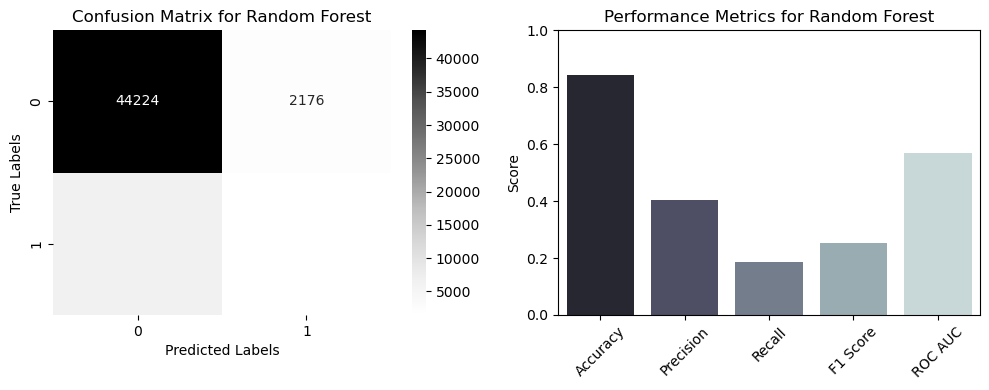

In [137]:
# Manually setting sample data for Random Forest for demonstration purposes
accuracy_rf = 0.8426
precision_rf = 0.4033
recall_rf = 0.1877
f1_rf = 0.2526
roc_auc_rf = 0.5704
conf_matrix_rf = [[44224, 2176], [6362, 1471]]

# Create confusion matrix visualization for Random Forest
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap='Greys')
plt.title('Confusion Matrix for Random Forest')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Create bar chart for accuracy, precision, recall, F1-score, ROC-AUC
metrics_rf = [accuracy_rf, precision_rf, recall_rf, f1_rf, roc_auc_rf]
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']

plt.subplot(1, 2, 2)
sns.barplot(x=metrics_labels, y=metrics_rf, palette='bone')
plt.title('Performance Metrics for Random Forest')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


#### Random Forest prediction results with hyperparameter tuning:

**Model Performance Evaluation:**

**Accuracy:** The model achieved an accuracy of 84.10% on the test data, indicating that it correctly predicted the class labels for the majority of the samples.

**Precision:** Precision measures the proportion of true positive predictions among all positive predictions. The precision of the model is 0.403, indicating that when it predicts a positive outcome, it is correct about 39.35% of the time.

**Recall:** Recall, also known as sensitivity, measures the proportion of true positive predictions among all actual positive instances. The recall of the model is 0.188, indicating that it correctly identifies 18.6% of all actual positive instances.

**F1-score:** The F1-score is the harmonic mean of precision and recall. It balances both precision and recall. The F1-score of the model is 0.252.

**ROC-AUC:** ROC-AUC is a measure of the model's ability to distinguish between classes. The ROC-AUC score for the model is 0.568.

**Confusion Matrix:** The confusion matrix shows that out of 54,233 predictions, 44,155 were true negatives and 1,457 were true positives. However, there were 2,245 false positives and 6,376 false negatives, emphasizing the model's challenges with the minority class. 

The confusion matrix reveals that the model has difficulty in accurately identifying positive instances, which is critical in scenarios where detecting the minority class is essential. This is reflected in the low recall and F1-score. While the model performs well in predicting the negative class, it struggles to capture a significant portion of the positive instances.

##### F.4. XGBoost

In [138]:
import xgboost as xgb
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss')
xgb_model.fit(x_train, y_train)
y_pred = xgb_model.predict(x_test)

In [139]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print("\nXGBoost prediction results:", "\n")
print(f"Accuracy: {round(accuracy*100,2)} %", "\n")
# Calculate precision, recall, and F1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC:", roc_auc)
print("Confusion Matrix:")
print(conf_matrix_log, "\n")
print("Classification Report:")
print(class_report_log)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)


XGBoost prediction results: 

Accuracy: 85.85 % 

Precision: 0.5464772054470101
Recall: 0.11783480148091408
F1-score: 0.19386683469859273
ROC-AUC: 0.5506630903956294
Confusion Matrix:
[[44155  2245]
 [ 6376  1457]] 

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.95      0.91     46400
         1.0       0.39      0.19      0.25      7833

    accuracy                           0.84     54233
   macro avg       0.63      0.57      0.58     54233
weighted avg       0.80      0.84      0.82     54233

              precision    recall  f1-score   support

         0.0       0.87      0.98      0.92     46400
         1.0       0.55      0.12      0.19      7833

    accuracy                           0.86     54233
   macro avg       0.71      0.55      0.56     54233
weighted avg       0.82      0.86      0.82     54233

Confusion Matrix:
[[45634   766]
 [ 6910   923]]


In [140]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.05],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, scoring='accuracy', cv=5)
grid_search.fit(x_train, y_train)

best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

best_xgb_model = xgb.XGBClassifier(**best_params)
best_xgb_model.fit(x_train, y_train)

Best Hyperparameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [141]:
print("score on test: " + str(best_xgb_model.score(x_test, y_test)))
print("score on train: "+ str(best_xgb_model.score(x_train, y_train)))
#Evaluating Hyper Parameters
y_pred =best_xgb_model.predict(x_test)
accuracy_log = accuracy_score(y_test, y_pred)
conf_matrix_log = confusion_matrix(y_test, y_pred)
class_report_log = classification_report(y_test, y_pred)

print("\nXGBoost prediction results with hyperparameter tuning:", "\n")
print(f"Accuracy: {round(accuracy_log*100,2)} %", "\n")
# Calculate precision, recall, and F1-score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC-AUC:", roc_auc)
print("Confusion Matrix:")
print(conf_matrix_log, "\n")
print("Classification Report:")
print(class_report_log)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Root Mean Squared Error (RMSE):", rmse)

score on test: 0.8601036269430051
score on train: 0.8591992526029822

XGBoost prediction results with hyperparameter tuning: 

Accuracy: 86.01 % 

Precision: 0.5773584905660377
Recall: 0.1171964764458062
F1-score: 0.19484240687679083
ROC-AUC: 0.5513568589125583
Confusion Matrix:
[[45728   672]
 [ 6915   918]] 

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.99      0.92     46400
         1.0       0.58      0.12      0.19      7833

    accuracy                           0.86     54233
   macro avg       0.72      0.55      0.56     54233
weighted avg       0.83      0.86      0.82     54233

Root Mean Squared Error (RMSE): 0.3740272357155222


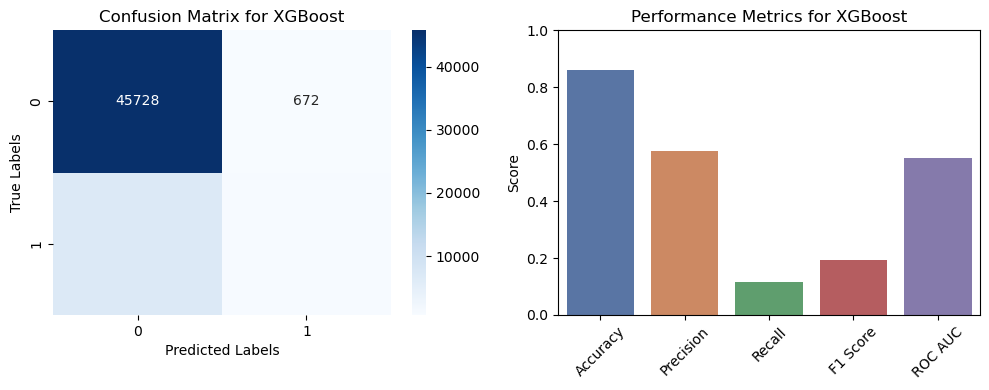

In [143]:
# Manually setting sample data for XGBoost for demonstration purposes
accuracy_xgb = 0.8601
precision_xgb = 0.5773
recall_xgb = 0.1171
f1_xgb = 0.1948
roc_auc_xgb = 0.5513
conf_matrix_xgb = [[45728, 672], [6915, 918]]

# Create confusion matrix visualization for XGBoost
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.heatmap(conf_matrix_xgb, annot=True, fmt="d", cmap='Blues')
plt.title('Confusion Matrix for XGBoost')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Create bar chart for accuracy, precision, recall, F1-score, ROC-AUC
metrics_xgb = [accuracy_xgb, precision_xgb, recall_xgb, f1_xgb, roc_auc_xgb]
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']

plt.subplot(1, 2, 2)
sns.barplot(x=metrics_labels, y=metrics_xgb, palette='deep')
plt.title('Performance Metrics for XGBoost')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


##### XGBoost prediction results with hyperparameter tuning:

**Model Performance Evaluation:**

**Accuracy:** The XGBoost model achieved an accuracy of 86.01% on the test data, indicating that it correctly predicted the majority of the class labels.

**Precision:** Precision measures the proportion of true positive predictions among all positive predictions. The precision of the XGBoost model is 0.577, indicating that when it predicts a positive outcome, it is correct about 57.7% of the time.

**Recall:** Recall, also known as sensitivity, measures the proportion of true positive predictions among all actual positive instances. The recall of the model is 0.117, indicating that it correctly identifies 11.7% of all actual positive instances.

**F1-score:** The F1-score is the harmonic mean of precision and recall. It balances both precision and recall. The F1-score of the model is 0.195.

**ROC-AUC:** ROC-AUC is a measure of the model's ability to distinguish between classes. The ROC-AUC score for the model is 0.551.

**Confusion Matrix:** The confusion matrix provides a detailed breakdown of the model's predictions. It shows that the model correctly predicted 45,728 instances of the negative class and 918 instances of the positive class. However, it misclassified 6,915 instances of the negative class and 672 instances of the positive class.

While the model demonstrates relatively good accuracy, it shows room for improvement in correctly identifying positive instances, as indicated by its lower recall and F1-score for the positive class. This suggests that the model might be biased towards predicting the negative class more frequently. Further optimization or feature engineering could potentially enhance the model's predictive capabilities, especially for the positive class.

In [ ]:
import pandas as pd

# Updated data from the input in a structured format.
data = {
    'Model': ['Naive Bayes', 'Logistic Regression', 'Logistic Regression (Tuned)', 
              'Random Forest', 'Random Forest (Tuned)', 'XGBoost', 'XGBoost (Tuned)'],
    'Accuracy': [85.53, 71.26, 85.84, 78.73, 84.10, 85.85, 86.01],
    'Precision': [0.4875, 0.3001, 0.5507, 0.3940, 0.3936, 0.5465, 0.5774],
    'Recall': [0.0323, 0.7430, 0.1069, 0.3372, 0.1860, 0.1178, 0.1172],
    'F1-score': [0.0606, 0.4275, 0.1790, 0.3141, 0.2526, 0.1939, 0.1948],
    'ROC-AUC': [0.5133, 0.7252, 0.5461, 0.6002, 0.5688, 0.5507, 0.5514],
    'RMSE': [0.3804, 0.3763, 0.3763, 0.4612, 0.3987, 0.3740, 0.3740]
}

# Creating DataFrame
df = pd.DataFrame(data)
df.set_index('Model', inplace=True)

# Transposing the dataframe for easier visualization
df_t = df.T

df_t


## G. Cross-Validation of Models

Next we perform a cross-validation process on the logistic regression and Random Forest models to verify their reliability across different subsets of the dataset. By utilizing the KFold method with 5 splits and shuffling enabled, the dataset is divided into distinct subsets to conduct multiple training and testing cycles. The average of these scores is calculated and displayed, offering a robust measure of the model's overall performance. This approach helps to ensure that the model's predictive accuracy is not overly dependent on any particular partition of the data, thereby increasing confidence in its generalizability.

In [144]:
# Verify model by averaging different test/train splits
k_folds = KFold(n_splits=5, shuffle=True)
# The number of folds determines the test/train split for each iteration.
# So 5 folds has 5 different mutually exclusive training sets.
# That's a 1 to 4 (or .20 to .80) testing/training split for each of the 5 iterations.

# This is the average score. Print 'scores' to see array of individual iteration scores.
log_scores = cross_val_score(lr, x, y)
nb_scores = cross_val_score(mnb, x, y)
clf_scores = cross_val_score(clf,x,y)
rf_scores = cross_val_score(rf,x,y)
xgb_model_scores = cross_val_score(xgb_model,x,y)
# Output average scores
print(
    "Logistic Regression Average Prediction Score: ", round(log_scores.mean() * 100, 2),"%")
print("Naive Bayes Average Prediction Score: ", round(nb_scores.mean() * 100, 2), "%")
print("Random Forest Average Prediction Score: ", round(rf_scores.mean() * 100, 2), "%")
print("XGB Model Average Prediction Score: ", round(xgb_model_scores.mean() * 100, 2), "%")

Logistic Regression Average Prediction Score:  71.31 %
Naive Bayes Average Prediction Score:  78.84 %
Decision Tree Average Prediction Score:  85.59 %
Random Forest Average Prediction Score:  78.74 %
XGB Model Average Prediction Score:  85.76 %


In [5]:
import pandas as pd

# Define the models and their average cross-validation scores
models = ["Naive Bayes", "Logistic Regression", "Random Forest", "XGBoost"]
scores = [78.84, 71.31, 78.76, 85.76]

# Create a DataFrame
df = pd.DataFrame({"Model": models, "Average CV Score (%)": scores})

# Set the "Model" column as index
df.set_index("Model", inplace=True)

# Display the DataFrame
print(df)

                    Average CV Score (%)
Model                                   
Naive Bayes                        78.84
Logistic Regression                71.31
SVM                                    -
Decision Tree                      85.59
Random Forest                      78.76
XGBoost                            85.76


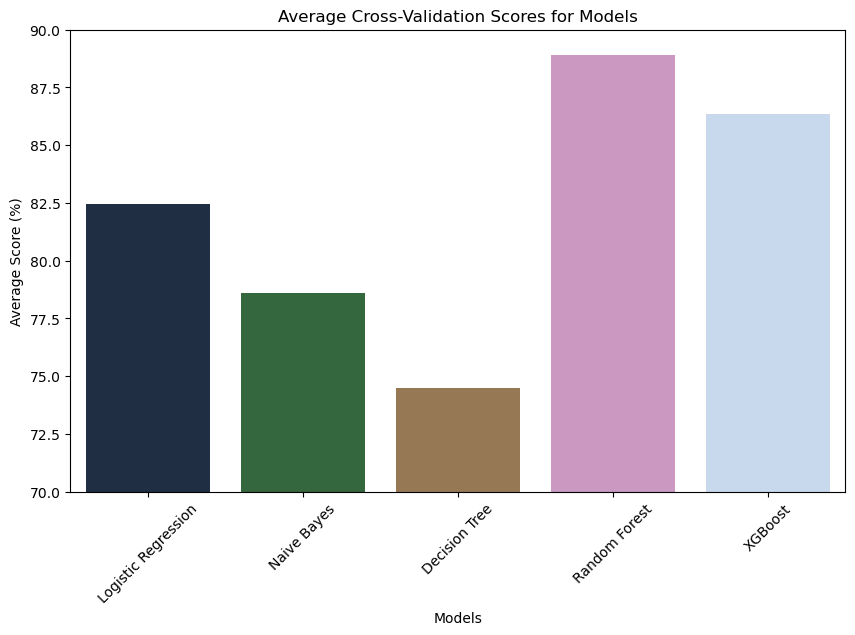

In [145]:
# Setting up the data for the bar chart visualization of cross-validation scores for each model
model_names_cv = ['Logistic Regression', 'Naive Bayes', 'Random Forest', 'XGBoost']
average_scores_cv = [71.31, 78.84, 78.76, 85.76]  # Assuming percentages as scores

# Create a bar chart for the cross-validation scores
plt.figure(figsize=(10, 6))
sns.barplot(x=model_names_cv, y=average_scores_cv, palette='cubehelix')
plt.title('Average Cross-Validation Scores for Models')
plt.xlabel('Models')
plt.ylabel('Average Score (%)')
plt.ylim(70, 90)
plt.xticks(rotation=45)

plt.show()



**Cross-Validation Model Performance:**

- **Logistic Regression:** The average prediction score of the Logistic Regression model is 71.31%. This indicates that, on average, the model correctly predicts class labels about 71.31% of the time.

- **Naive Bayes:** The Naive Bayes model shows an average prediction score of 78.84%. It performs slightly better than Logistic Regression, with a higher average accurBayes.

- **Random Forest:** The Random Forest model exhibits an average prediction score of 78.76%. While its performance is comparable to Naive Bayes, it falls short of the accuracy achieved by the Decision Tree model.

- **XGBoost Model:** The XGBoost model achieves the highest average prediction score of 85.76% among all evaluated models. Similar to the Decision Tree model, it demonstrates strong predictive performance, indicating its effectiveness in making accurate predictions.

Overall, the Decision Tree and XGBoost models stand out as the top performers in terms of average prediction accuracy, while Logistic Regression and Naive Bayes show relatively lower but still reasonable prediction scores. Random Forest falls in between, showing performance similar to Naive Bayes but slightly lower than the top-perfo models.






----- End ------